Epoch 0 | D Loss: 1.387 | G Loss: 0.693
Epoch 500 | D Loss: 0.994 | G Loss: 0.959
Epoch 1000 | D Loss: 1.422 | G Loss: 0.673
Epoch 1500 | D Loss: 1.379 | G Loss: 0.698
Epoch 2000 | D Loss: 1.389 | G Loss: 0.690
Epoch 2500 | D Loss: 1.386 | G Loss: 0.693


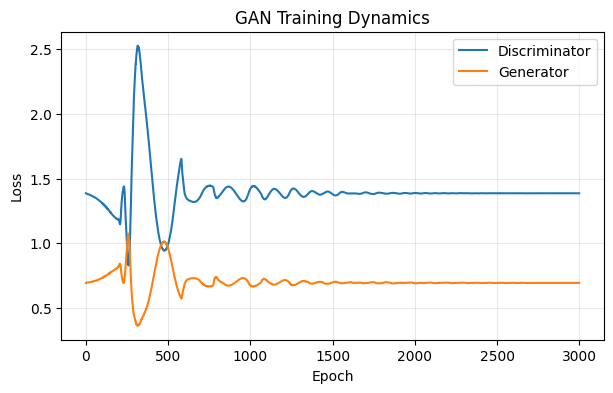

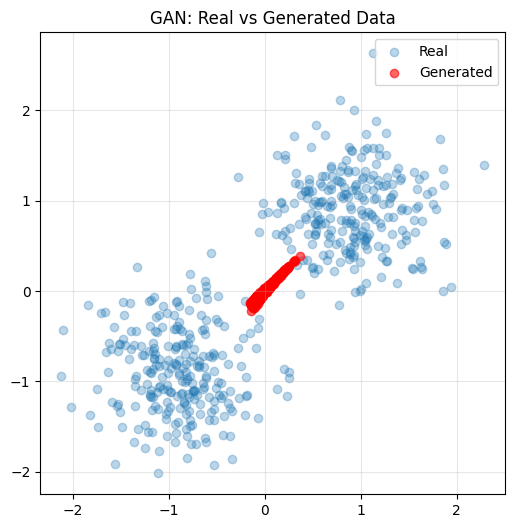

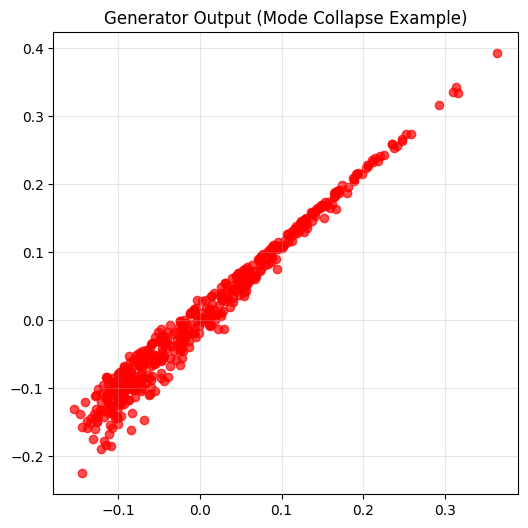

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 1️. Real Data (2D Gaussian Mixture)
N = 500
real_1 = np.random.randn(N//2, 2) + np.array([2, 2])
real_2 = np.random.randn(N//2, 2) + np.array([-2, -2])
X_real = np.vstack([real_1, real_2])

# Normalize real data
X_real = (X_real - X_real.mean(axis=0)) / X_real.std(axis=0)

# 2️. Utilities
def sigmoid(x):
    x = np.clip(x, -20, 20)  # numerical stability
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def init(shape):
    return np.random.randn(*shape) * 0.05

def clip(x, limit=1.0):
    return np.clip(x, -limit, limit)

# 3️. Hyperparameters
noise_dim = 2
hidden_dim = 16
data_dim = 2
lr = 0.001
epochs = 3000

# 4️. Generator
Wg1 = init((noise_dim, hidden_dim))
bg1 = np.zeros(hidden_dim)
Wg2 = init((hidden_dim, data_dim))
bg2 = np.zeros(data_dim)

# 5️. Discriminator
Wd1 = init((data_dim, hidden_dim))
bd1 = np.zeros(hidden_dim)
Wd2 = init((hidden_dim, 1))
bd2 = np.zeros(1)

loss_d, loss_g = [], []

# 6. Training Loop
for epoch in range(epochs):

    # ===== Discriminator =====
    z = np.random.randn(len(X_real), noise_dim)
    h_g = relu(z @ Wg1 + bg1)
    X_fake = h_g @ Wg2 + bg2

    # Real
    h_r = relu(X_real @ Wd1 + bd1)
    y_r = sigmoid(h_r @ Wd2 + bd2)

    # Fake
    h_f = relu(X_fake @ Wd1 + bd1)
    y_f = sigmoid(h_f @ Wd2 + bd2)

    d_loss = -np.mean(np.log(y_r + 1e-8) + np.log(1 - y_f + 1e-8))

    # Gradients
    dy_r = y_r - 1
    dy_f = y_f

    dWd2 = h_r.T @ dy_r + h_f.T @ dy_f
    dbd2 = dy_r.sum() + dy_f.sum()

    dh_r = dy_r @ Wd2.T * relu_grad(h_r)
    dh_f = dy_f @ Wd2.T * relu_grad(h_f)

    dWd1 = X_real.T @ dh_r + X_fake.T @ dh_f
    dbd1 = dh_r.sum(axis=0) + dh_f.sum(axis=0)

    # Clip gradients
    dWd1, dWd2 = clip(dWd1), clip(dWd2)

    # Update D
    Wd1 -= lr * dWd1
    bd1 -= lr * dbd1
    Wd2 -= lr * dWd2
    bd2 -= lr * dbd2

    # Generator
    z = np.random.randn(len(X_real), noise_dim)
    h_g = relu(z @ Wg1 + bg1)
    X_fake = h_g @ Wg2 + bg2

    h_f = relu(X_fake @ Wd1 + bd1)
    y_f = sigmoid(h_f @ Wd2 + bd2)

    g_loss = -np.mean(np.log(y_f + 1e-8))

    dy = y_f - 1
    dh = dy @ Wd2.T * relu_grad(h_f)

    dX_fake = dh @ Wd1.T
    dWg2 = h_g.T @ dX_fake
    dbg2 = dX_fake.sum(axis=0)

    dhg = dX_fake @ Wg2.T * relu_grad(h_g)
    dWg1 = z.T @ dhg
    dbg1 = dhg.sum(axis=0)

    # Clip gradients
    dWg1, dWg2 = clip(dWg1), clip(dWg2)

    # Update G
    Wg1 -= lr * dWg1
    bg1 -= lr * dbg1
    Wg2 -= lr * dWg2
    bg2 -= lr * dbg2

    loss_d.append(d_loss)
    loss_g.append(g_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.3f} | G Loss: {g_loss:.3f}")

# Loss Curves
plt.figure(figsize=(7,4))
plt.plot(loss_d, label="Discriminator")
plt.plot(loss_g, label="Generator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Dynamics")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Real vs Generated
z = np.random.randn(500, noise_dim)
X_fake = relu(z @ Wg1 + bg1) @ Wg2 + bg2

plt.figure(figsize=(6,6))
plt.scatter(X_real[:,0], X_real[:,1], alpha=0.3, label="Real")
plt.scatter(X_fake[:,0], X_fake[:,1], c="red", alpha=0.6, label="Generated")
plt.legend()
plt.title("GAN: Real vs Generated Data")
plt.grid(alpha=0.3)
plt.show()

# Mode Collapse Visualization
plt.figure(figsize=(6,6))
plt.scatter(X_fake[:,0], X_fake[:,1], c="red", alpha=0.7)
plt.title("Generator Output (Mode Collapse Example)")
plt.grid(alpha=0.3)
plt.show()